# Baseline GPR: Batchwise SGD with Seasonal Interaction Kernel

Random 80/20 split baseline using **batchwise SGD** training following
Patel et al. (2022, AAAI). Each training epoch samples a fresh batch of 4000
from the full training set, providing implicit regularization.

**Kernel:** `Base_RBF_ARD + AOT×Season + SmogI/P×Season + Residual_Season`

In [1]:
import sys
sys.path.insert(0, '../../..')
import pandas as pd
import numpy as np
import torch
import gpytorch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 1. Load and Prepare Data

In [2]:
pm_all = pd.read_csv("../../../../data/pm25_data_complete_2003_2021_smogI_031026.csv", low_memory=False)
pm_fixed = pd.read_csv('../../../../eda/pm25_locs_with_states.csv')

mt_sites = pm_fixed[pm_fixed['state'] == 'MT'].copy()
mt_ll_ids = set(mt_sites['ll_id'].values)

pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year
pm_mt = pm_all[(pm_all['ll_id'].isin(mt_ll_ids)) & (pm_all['year'].isin([2018, 2019]))].copy()

time_varying_features = ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP']
static_features = ['lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing']
available_tv = [f for f in time_varying_features if f in pm_mt.columns]
available_static = [f for f in static_features if f in mt_sites.columns]

pm_mt_subset = pm_mt[['ll_id', 'date', 'pm25'] + available_tv].copy()
mt_static = mt_sites[['ll_id'] + available_static].copy()
df = pm_mt_subset.merge(mt_static, on='ll_id', how='left')
df['day_of_year'] = df['date'].dt.dayofyear

feature_cols = available_tv + available_static + ['day_of_year']
aot_idx = feature_cols.index('aot')
smogI_idx = feature_cols.index('smogI')
smogP_idx = feature_cols.index('smogP')
doy_idx = feature_cols.index('day_of_year')
seasonal_interaction_features = {'aot', 'smogI', 'smogP', 'day_of_year'}
base_indices = [i for i, f in enumerate(feature_cols) if f not in seasonal_interaction_features]

df_clean = df.dropna(subset=feature_cols + ['pm25']).copy()
print(f"Clean data: {len(df_clean):,} observations, {df_clean['ll_id'].nunique()} sites")
print(f"Features ({len(feature_cols)}): {feature_cols}")

Clean data: 15,572 observations, 32 sites
Features (17): ['aot', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'smogP', 'lat', 'lon', 'logpd2500g', 'minf_5000', 'sd50k', 'heavy_industrial_ind1', 'housing', 'day_of_year']


## 2. Model and Batchwise Training

In [3]:
class SeasonalInteractionGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood,
                 base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx,
                 period_init=None):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.base_kernel = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=len(base_indices),
                                        active_dims=torch.tensor(base_indices)))

        self.aot_rbf = gpytorch.kernels.RBFKernel(active_dims=torch.tensor([aot_idx]))
        self.aot_periodic = gpytorch.kernels.PeriodicKernel(active_dims=torch.tensor([doy_idx]))
        self.aot_seasonal_rbf = gpytorch.kernels.RBFKernel(active_dims=torch.tensor([doy_idx]))
        if period_init is not None:
            self.aot_periodic.initialize(period_length=period_init)
        self.summer_kernel = gpytorch.kernels.ScaleKernel(
            self.aot_rbf * self.aot_periodic * self.aot_seasonal_rbf)

        self.smog_rbf = gpytorch.kernels.RBFKernel(
            ard_num_dims=2, active_dims=torch.tensor([smogI_idx, smogP_idx]))
        self.smog_periodic = gpytorch.kernels.PeriodicKernel(active_dims=torch.tensor([doy_idx]))
        self.smog_seasonal_rbf = gpytorch.kernels.RBFKernel(active_dims=torch.tensor([doy_idx]))
        if period_init is not None:
            self.smog_periodic.initialize(period_length=period_init)
        self.winter_kernel = gpytorch.kernels.ScaleKernel(
            self.smog_rbf * self.smog_periodic * self.smog_seasonal_rbf)

        self.residual_periodic = gpytorch.kernels.PeriodicKernel(active_dims=torch.tensor([doy_idx]))
        self.residual_seasonal_rbf = gpytorch.kernels.RBFKernel(active_dims=torch.tensor([doy_idx]))
        if period_init is not None:
            self.residual_periodic.initialize(period_length=period_init)
        self.seasonal_kernel = gpytorch.kernels.ScaleKernel(
            self.residual_periodic * self.residual_seasonal_rbf)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = (self.base_kernel(x) + self.summer_kernel(x)
                   + self.winter_kernel(x) + self.seasonal_kernel(x))
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [4]:
def train_gp_batchwise(full_train_x, full_train_y, batch_size,
                       base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx,
                       period_init, n_epochs=200, lr=0.1, patience=20, verbose=True):
    """Train GP with batchwise SGD — fresh batch each epoch."""
    n_train = len(full_train_x)
    actual_batch = min(batch_size, n_train)

    # Initialize with first batch
    idx = torch.randperm(n_train)[:actual_batch]
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
    model = SeasonalInteractionGP(
        full_train_x[idx], full_train_y[idx], likelihood,
        base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx, period_init
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    losses = []
    best_smoothed = float('inf')
    best_state = None
    best_lik_state = None
    patience_counter = 0
    smoothed_loss = None
    stopped_epoch = n_epochs

    for epoch in range(n_epochs):
        model.train()
        likelihood.train()

        # Fresh batch each epoch
        idx = torch.randperm(n_train)[:actual_batch]
        batch_x = full_train_x[idx]
        batch_y = full_train_y[idx]
        model.set_train_data(batch_x, batch_y, strict=False)

        optimizer.zero_grad()
        output = model(batch_x)
        loss = -mll(output, batch_y)
        loss.backward()
        optimizer.step()

        current = loss.item()
        losses.append(current)

        # EMA for early stopping
        smoothed_loss = current if smoothed_loss is None else 0.9 * smoothed_loss + 0.1 * current

        if smoothed_loss < best_smoothed:
            best_smoothed = smoothed_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_lik_state = {k: v.clone() for k, v in likelihood.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience > 0 and patience_counter >= patience:
            stopped_epoch = epoch + 1
            break

        if verbose and (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}, Loss: {current:.4f}, EMA: {smoothed_loss:.4f}")

    # Restore best
    model.load_state_dict(best_state)
    likelihood.load_state_dict(best_lik_state)

    # Set conditioning data for inference
    infer_idx = torch.randperm(n_train)[:actual_batch]
    model.set_train_data(full_train_x[infer_idx], full_train_y[infer_idx], strict=False)

    print(f"  Stopped at epoch {stopped_epoch}, best EMA loss: {best_smoothed:.4f}")
    return model, likelihood, losses

## 3. Train and Evaluate

In [5]:
BATCH_SIZE = 4000
N_EPOCHS = 200
PATIENCE = 20

# Random 80/20 split
X = df_clean[feature_cols].values
y = np.log(df_clean['pm25'].values + 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
period_init = 365.25 / scaler.scale_[doy_idx]

train_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
train_y = torch.tensor(y_train, dtype=torch.float32).to(device)
test_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

print(f"Train: {len(train_x):,}, Test: {len(X_test):,}")
print(f"Batch size: {BATCH_SIZE}, Epochs: {N_EPOCHS}, Patience: {PATIENCE}")

import time
start = time.perf_counter()
model, likelihood, losses = train_gp_batchwise(
    train_x, train_y, BATCH_SIZE,
    base_indices, aot_idx, smogI_idx, smogP_idx, doy_idx,
    period_init, N_EPOCHS, patience=PATIENCE)
train_time = time.perf_counter() - start
print(f"Training time: {train_time:.1f}s")

Train: 12,457, Test: 3,115
Batch size: 4000, Epochs: 200, Patience: 20


  Epoch 50, Loss: 0.6508, EMA: 0.6676


  Epoch 100, Loss: 0.6274, EMA: 0.6269


  Stopped at epoch 141, best EMA loss: 0.6194
Training time: 20.4s


In [6]:
# Predict
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(test_x))
    pred_mean = pred.mean.cpu().numpy()
    pred_var = pred.variance.cpu().numpy()

# Log scale metrics
rmse_log = np.sqrt(np.mean((pred_mean - y_test)**2))
mae_log = np.mean(np.abs(pred_mean - y_test))
ss_res = np.sum((y_test - pred_mean)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_log = 1 - (ss_res / ss_tot)

# Original scale
pred_pm25 = np.exp(pred_mean) - 1
actual_pm25 = np.exp(y_test) - 1
rmse_orig = np.sqrt(np.mean((pred_pm25 - actual_pm25)**2))
ss_res_o = np.sum((actual_pm25 - pred_pm25)**2)
ss_tot_o = np.sum((actual_pm25 - np.mean(actual_pm25))**2)
r2_orig = 1 - (ss_res_o / ss_tot_o)

print("=" * 50)
print("Baseline Results (Batchwise SGD)")
print("=" * 50)
print(f"Log scale:  RMSE={rmse_log:.4f}, R²={r2_log:.4f}")
print(f"Orig scale: RMSE={rmse_orig:.2f} μg/m³, R²={r2_orig:.4f}")

Baseline Results (Batchwise SGD)
Log scale:  RMSE=0.4201, R²=0.6872
Orig scale: RMSE=4.04 μg/m³, R²=0.6415


## 4. Training Loss

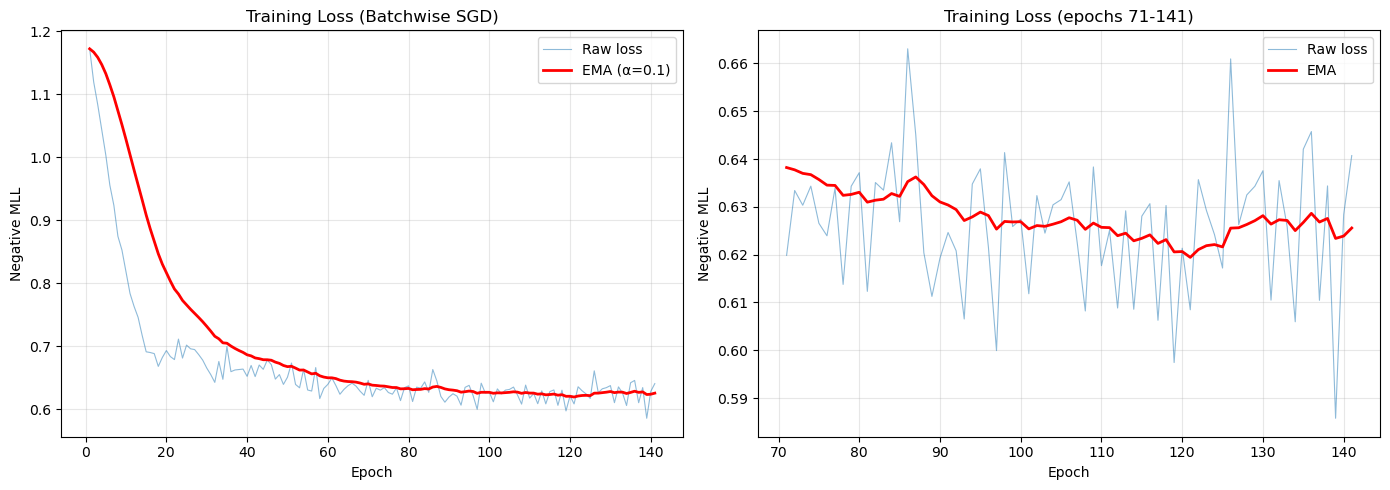

Final EMA loss: 0.6256


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(losses) + 1)
axes[0].plot(epochs, losses, alpha=0.5, linewidth=0.8, label='Raw loss')
# EMA overlay
ema = [losses[0]]
for l in losses[1:]:
    ema.append(0.9 * ema[-1] + 0.1 * l)
axes[0].plot(epochs, ema, 'r-', linewidth=2, label='EMA (α=0.1)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Negative MLL')
axes[0].set_title('Training Loss (Batchwise SGD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoomed view of last half
mid = len(losses) // 2
axes[1].plot(range(mid+1, len(losses)+1), losses[mid:], alpha=0.5, linewidth=0.8, label='Raw loss')
axes[1].plot(range(mid+1, len(losses)+1), ema[mid:], 'r-', linewidth=2, label='EMA')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Negative MLL')
axes[1].set_title(f'Training Loss (epochs {mid+1}-{len(losses)})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final EMA loss: {ema[-1]:.4f}")

## 5. Predictions

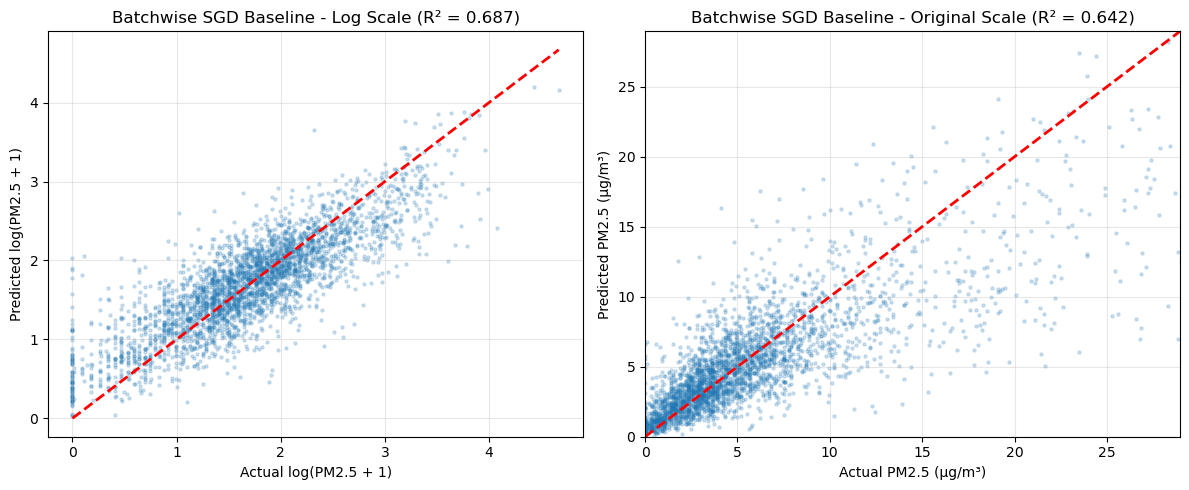

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, pred_mean, alpha=0.2, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(PM2.5 + 1)')
axes[0].set_ylabel('Predicted log(PM2.5 + 1)')
axes[0].set_title(f'Batchwise SGD Baseline - Log Scale (R² = {r2_log:.3f})')
axes[0].grid(True, alpha=0.3)

max_val = np.percentile(np.concatenate([actual_pm25, pred_pm25]), 99)
axes[1].scatter(actual_pm25, pred_pm25, alpha=0.2, s=5)
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2)
axes[1].set_xlabel('Actual PM2.5 (μg/m³)')
axes[1].set_ylabel('Predicted PM2.5 (μg/m³)')
axes[1].set_title(f'Batchwise SGD Baseline - Original Scale (R² = {r2_orig:.3f})')
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()